# QAOA — Demo

Walks through `algorithms.qaoa` end to end: build the cost/mixer gates for
a MaxCut instance, visualize the circuit and its measurement histogram
before and after parameter optimization, and solve MaxCut via
`solve_maxcut()`.

See [../math.md](../math.md) for the theory — including why this is a
fundamentally different guarantee shape from every other algorithm in this
repo — and [../paper.md](../paper.md) for the circuit derivation this
notebook exercises.

In [1]:
# Make the repo importable regardless of the working directory this
# notebook is executed from (e.g. `jupyter execute` defaults to the
# notebook's own directory, not the repo root).
import sys
from pathlib import Path

repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

In [2]:
from algorithms.qaoa import visualization
from algorithms.qaoa.circuit import build_qaoa_circuit
from algorithms.qaoa.execution import AerExecutor
from algorithms.qaoa.implementation import solve_maxcut
from algorithms.qaoa.problems import MaxCutProblem

# A triangle: every pair of vertices is connected. Max cut = 2 (any 2-1 split).
n_qubits = 3
edges = [(0, 1), (1, 2), (0, 2)]
problem = MaxCutProblem(n_qubits, edges)
executor = AerExecutor()
print(f"Graph: {edges}")

Graph: [(0, 1), (1, 2), (0, 2)]


## The circuit (unoptimized parameters)

`H^n` (uniform superposition over all 8 candidate cuts), then one layer of
(cost gate, mixer gate), then measure.

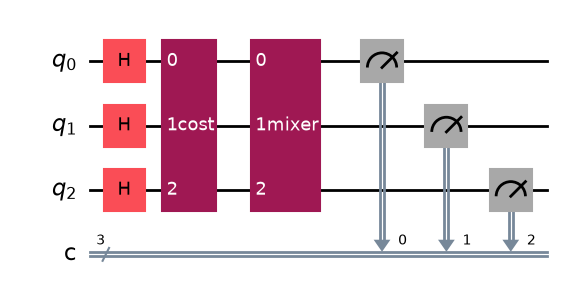

In [3]:
circuit = build_qaoa_circuit(problem, gammas=[0.5], betas=[0.3])
visualization.circuit_figure(circuit)

## Running it with arbitrary (non-optimized) parameters

Even without any parameter tuning, the circuit already favors higher-cost
cuts over the trivial all-same partitions (`000`/`111`, cost 0) — that's
visible directly in the histogram below.

100:  179  cost=2
110:  175  cost=2
010:  170  cost=2
101:  161  cost=2
001:  160  cost=2
011:  151  cost=2
000:    3  cost=0
111:    1  cost=0


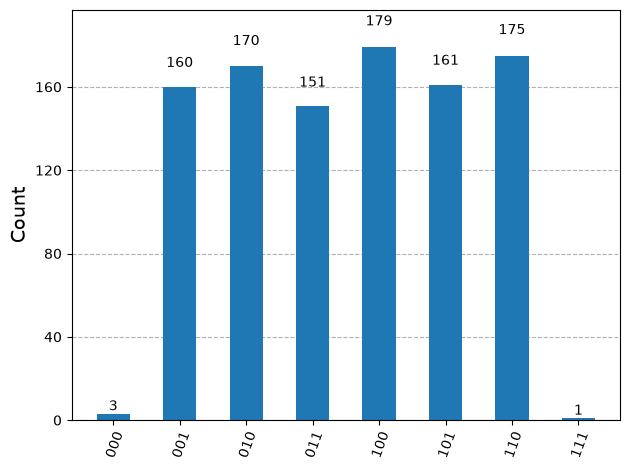

In [4]:
counts = executor.run(circuit, shots=1000)
for bitstring, count in sorted(counts.items(), key=lambda kv: -kv[1]):
    print(f"{bitstring}: {count:4d}  cost={problem.cost_value(bitstring):.0f}")
visualization.plot_measurement_histogram(counts)

## `solve_maxcut`: the full classical-quantum loop

`scipy.optimize.minimize` (COBYLA) tunes `(gammas, betas)` against the
sampled expectation value, then a final higher-shot-count run reads off
the best-measured cut.

In [5]:
import itertools

bitstring, cost = solve_maxcut(n_qubits, edges, p=1)
print(f"Found cut: {bitstring}  cost={cost}")

# Brute-force the true optimum for comparison (feasible only for small graphs)
all_bitstrings = itertools.product("01", repeat=n_qubits)
optimal = max(problem.cost_value("".join(bits)) for bits in all_bitstrings)
print(f"True optimum: {optimal}")
assert cost == optimal

Found cut: 110  cost=2.0
True optimum: 2.0
